In [4]:
"""IMPORTAR"""

import pandas as pd
import os
from scipy.interpolate import PchipInterpolator
import numpy as np
import copy
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
import matplotlib.pyplot as plt

import importlib
import funciones
importlib.reload(funciones)
print()
# from funciones import indice_J, generar_uniforme_centrada, interpolador, remover_duplicados

from music21 import *
environment.set('musescoreDirectPNGPath', r"C:\Program Files\MuseScore 4\bin\MuseScore4.exe")


In [161]:
import pandas as pd

# Supongamos que tienes dos DataFrames:
df = pd.read_csv("betas_J_Jinterp.csv") #betas  
df = pd.read_csv("salida_multi.csv") #betas  
df2 = pd.read_csv("salida_shuffle.csv") #shuffle
df2['Fecha de nacimiento'] = df['Fecha de nacimiento']
df = df.dropna(subset=['Beta_multi','J','J_interp10'])
print(pearsonr(df['Beta_multi'], df['Jmulti'])[0])

-0.09169548473038644


In [136]:
np.std(df.loc[df['Genero'] == "Sonata", 'Beta'].to_numpy())
df.loc[df['Compositor'] == "sousa"]

,Compositor,Fecha de nacimiento,Titulo de la obra,Movimiento o indicacion de tempo,Opus,Numero de la obra,Genero,Archivo,Beta,J,J_interp10,notes_durations
25142,sousa,1854.0,The Liberty Bell March\n,NaN,NaN,NaN,NaN,liberty-bell.krn,0.15,0.994617,0.997424,4.0
25143,sousa,1854.0,King Cotton\n,NaN,NaN,NaN,NaN,kingcotton.krn,0.17,0.944824,0.950179,4.0
25144,sousa,1854.0,The Invincible Eagle March\n,NaN,NaN,NaN,NaN,invincible-eagle.krn,0.34,0.990905,0.981254,4.0
25145,sousa,1854.0,Hands Across the Sea\n,NaN,NaN,NaN,NaN,hands-sea.krn,-0.01,0.922261,0.928293,5.0
25146,sousa,1854.0,Washington Post March\n,Tempo marziale\n,NaN,NaN,NaN,washington-post.krn,0.13,0.958615,0.969957,4.0
25147,sousa,1854.0,The Gladiator March\n,NaN,NaN,NaN,NaN,gladiator.krn,-0.16,0.927740,0.931105,5.0
25148,sousa,1854.0,Transit of Venus March\n,NaN,NaN,NaN,NaN,venus-transit.krn,-0.04,0.992526,0.991852,3.0
25149,sousa,1854.0,Hail to the Spirit of Liberty\n,NaN,NaN,NaN,NaN,spirit-liberty.krn,0.12,0.955918,0.968425,13.0
25150,sousa,1854.0,El Capitan March\n,NaN,NaN,NaN,NaN,el-capitan.krn,0.41,0.977704,0.974824,4.0
25151,sousa,1854.0,Stars and Strips Forever March\n,NaN,NaN,NaN,NaN,stars-stripes.krn,-0.12,0.948897,0.949871,4.0


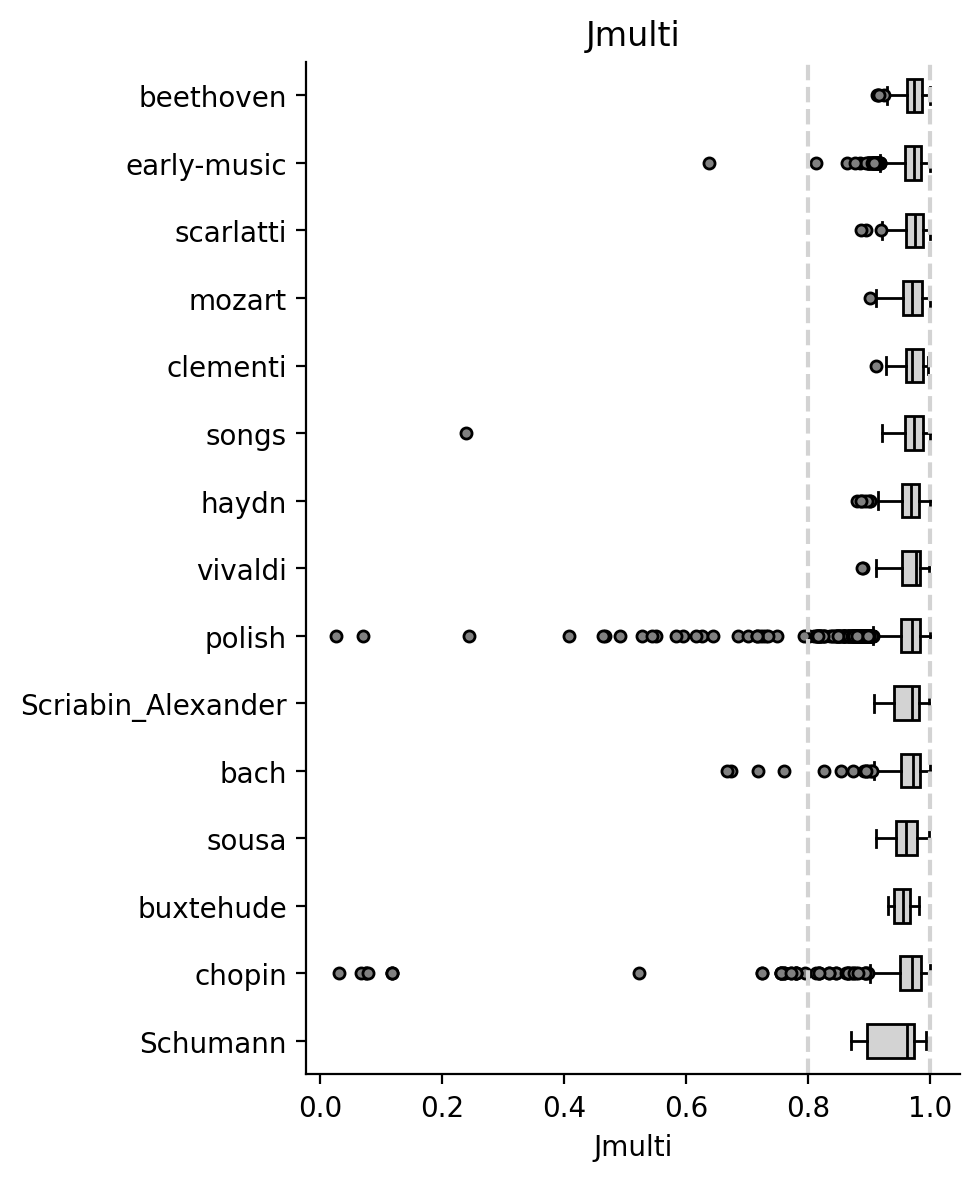

In [163]:
import matplotlib.pyplot as plt
import numpy as np

variable = "Jmulti"

# Filtrar compositores con al menos 9 datos
composers = list(df['Compositor'].unique())
composers = [x for x in composers if len(df[df['Compositor'] == x]) >= 9]

# Obtener listas de valores por compositor
data_by_composer = [df.loc[df['Compositor'] == composer, variable].to_numpy() for composer in composers]

# Calcular medias para ordenar
means = [np.mean(values) for values in data_by_composer]
sorted_indices = np.argsort(means)[::-1]

# Ordenar compositores y datos
composers_sorted = np.array(composers)[sorted_indices]
data_sorted = [data_by_composer[i] for i in sorted_indices]

# Crear figura
fig, ax = plt.subplots(figsize=(5, 6))

# Dibujar boxplots horizontales
ax.boxplot(data_sorted, vert=False, patch_artist=True,
           boxprops=dict(facecolor='lightgray', color='black'),
           medianprops=dict(color='black'),
           whiskerprops=dict(color='black'),
           capprops=dict(color='black'),
           flierprops=dict(marker='o', markersize=4, markerfacecolor='gray', markeredgecolor='black'))

# Etiquetas
y_pos = np.arange(1, len(composers_sorted) + 1)
ax.set_yticks(y_pos)
ax.set_yticklabels(composers_sorted)
ax.invert_yaxis()  # El primero arriba
ax.set_xlabel(variable)
# ax.set_xlim(-1,3)

# Líneas de referencia opcionales
ax.axvline(0.8, linestyle='--', color='lightgray')
ax.axvline(1.0, linestyle='--', color='lightgray')

# Estética
ax.tick_params(axis='x', bottom=True, top=False, labelbottom=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.title(variable)
plt.tight_layout()
plt.show()


In [5]:
def process_notes(m21_data, start_measure=1):
    notes = []
    
    for part in m21_data.parts:
        for note in part.flatten().notes:
            try:
                measure = note.measureNumber + (start_measure - 1)
                start = float(note.offset)
                duration = float(note.quarterLength)
                
                if note.isChord:
                    for chord_note in note.pitches:
                        pitch = float(chord_note.ps)
                        notes.append([measure, start, start + duration, duration, pitch])
                else:
                    pitch = float(note.pitch.ps)
                    notes.append([measure, start, start + duration, duration, pitch])
            except:
                try:
                    start = float(note.offset)
                except:
                    try:
                        numer = note.offset.numerator
                        denom = note.offset.denominator
                        start = float(numer / denom)
                    except:
                        start = float(note.offset)
                
                try:
                    duration = float(note.quarterLength)
                except:
                    try:
                        numer = note.quarterLength.numerator
                        denom = note.quarterLength.denominator
                        duration = float(numer / denom)
                    except:
                        duration = float(note.quarterLength)
                
                for chord_note in note.pitches:
                    pitch = float(chord_note.ps)
                    notes.append([measure, start, start + duration, duration, pitch])
    
    all_notes = np.array(notes, dtype=object)
    n_measures = int(np.max(all_notes[:, 0]))
    
    timesig = []
    lquarters = []
    for i in range(n_measures + 1):
        try:
            ts = m21_data.parts[0].measure(i).timeSignature
            timesig.append([i, ts.ratioString])
            nquarters = ts.numerator / ts.denominator * 4
            lquarters.append([i, nquarters])
        except:
            pass
    
    measures_piece = []
    if len(timesig) > 1:
        for n_ts in range(1, len(timesig)):
            last_m = timesig[n_ts][0]
            first_m = timesig[n_ts - 1][0]
            ix = np.where((all_notes[:, 0] >= first_m) & (all_notes[:, 0] <= last_m))
            m_ts = [timesig[n_ts - 1][1]] * len(ix[0])
            measures_piece.append(np.column_stack((all_notes[ix], m_ts)))
        
        last_m = n_measures
        first_m = timesig[-1][0]
        ix = np.where((all_notes[:, 0] >= first_m) & (all_notes[:, 0] <= last_m))
        m_ts = [timesig[-1][1]] * len(ix[0])
        measures_piece.append(np.column_stack((all_notes[ix], m_ts)))
    else:
        m_ts = [timesig[0][1]] * len(all_notes)
        measures_piece.append(np.column_stack((all_notes, m_ts)))
    
    out_measures = np.vstack(measures_piece)
    return out_measures[np.lexsort((out_measures[:, 1].astype(float), out_measures[:, 0].astype(float)))]

def midi_to_note(midi_number):
    note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    octave = midi_number // 12 - 1
    note_index = midi_number % 12
    note = note_names[note_index]
    return f"{note}{octave}"

def midi_to_note_list(array):
    notas = []
    for x in array:
        # notas.append(columna[i])
        notas.append(midi_to_note(int(x)))
    return notas


def extract_midi_sequence(notes_matrix):
    unique_starts = np.unique(notes_matrix[:, 1].astype(float))
    midi_sequence = []
    
    for start in unique_starts:
        notes_at_start = notes_matrix[notes_matrix[:, 1].astype(float) == start]
        highest_pitch = np.max(notes_at_start[:, 4].astype(float))
        midi_sequence.append(highest_pitch)
    
    return midi_sequence

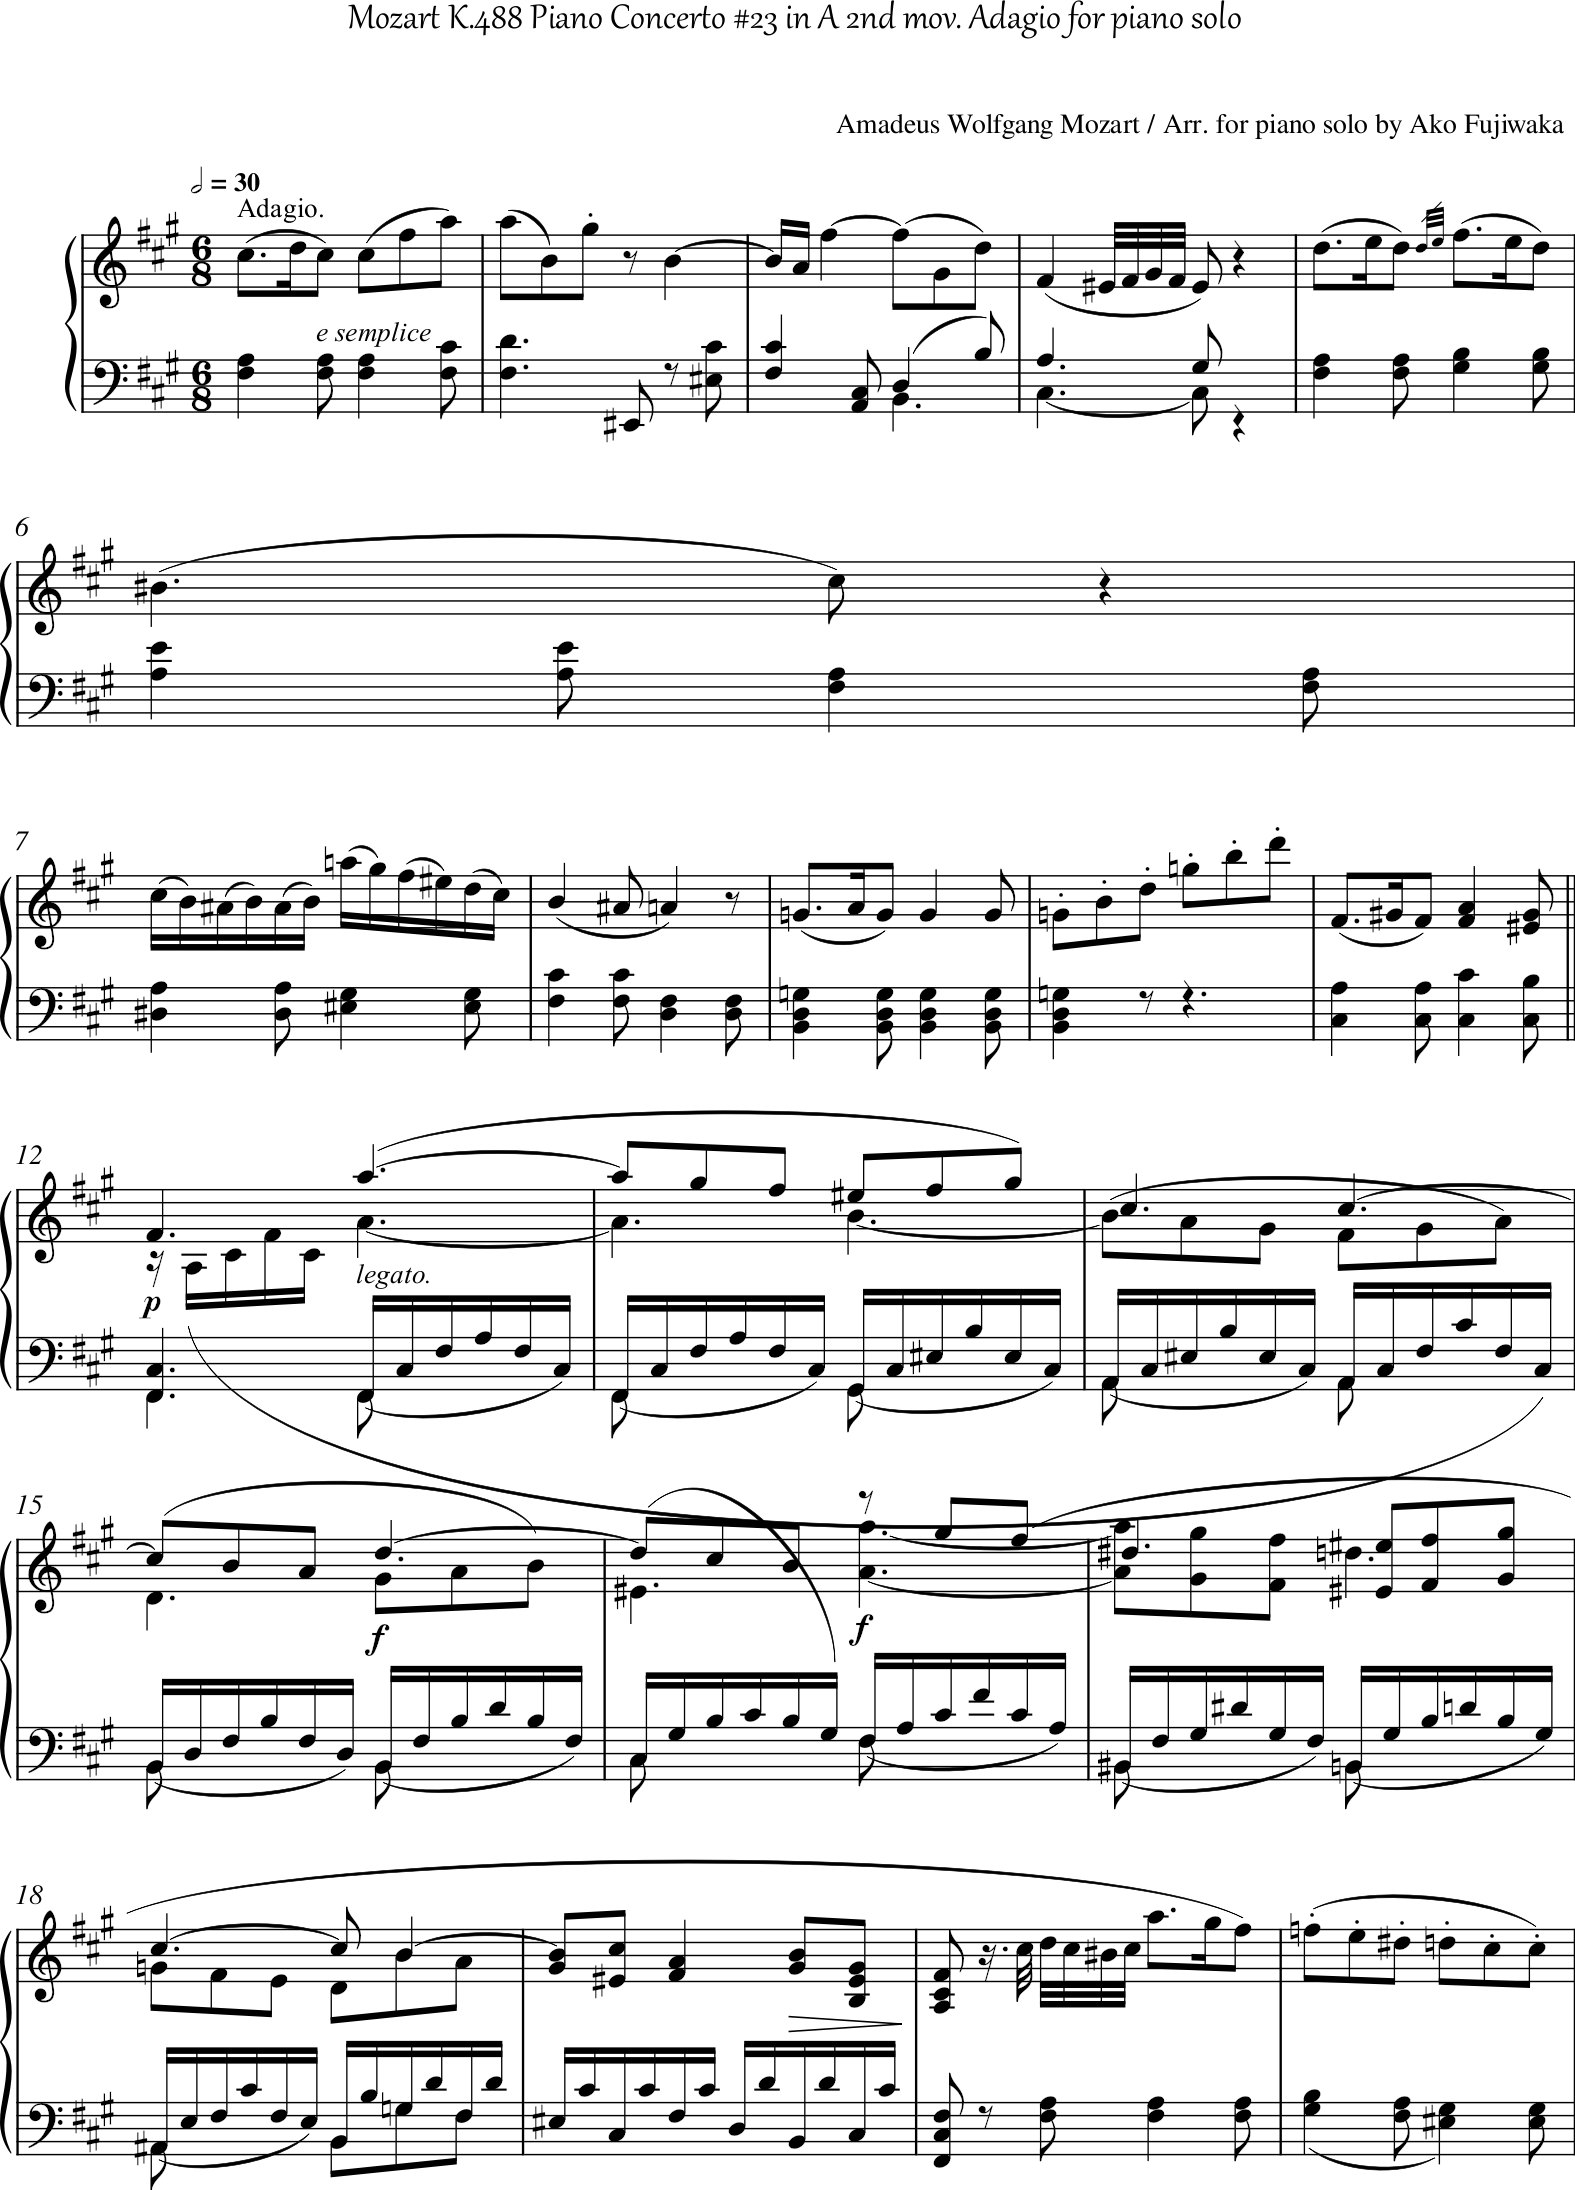

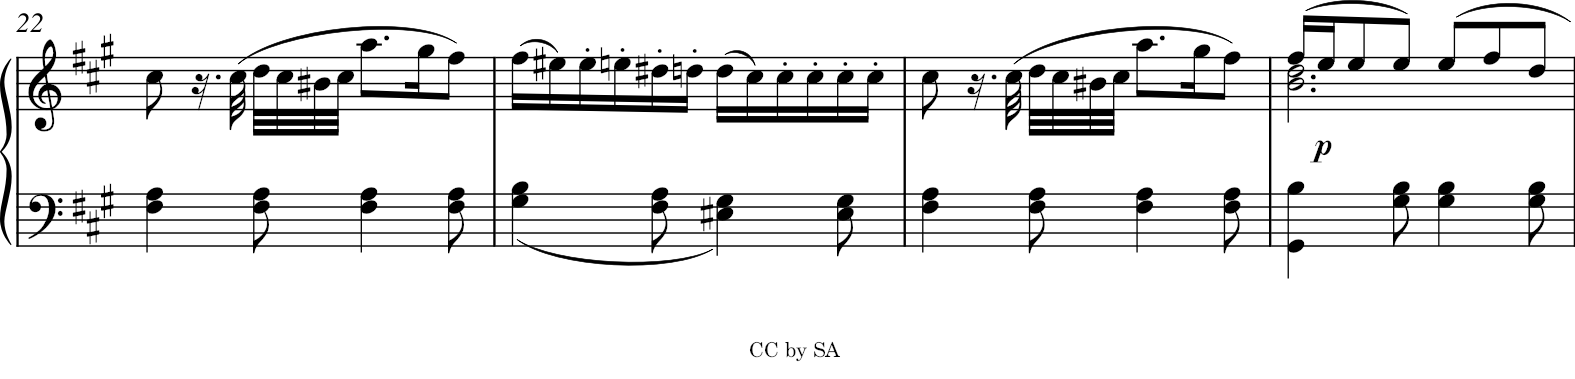

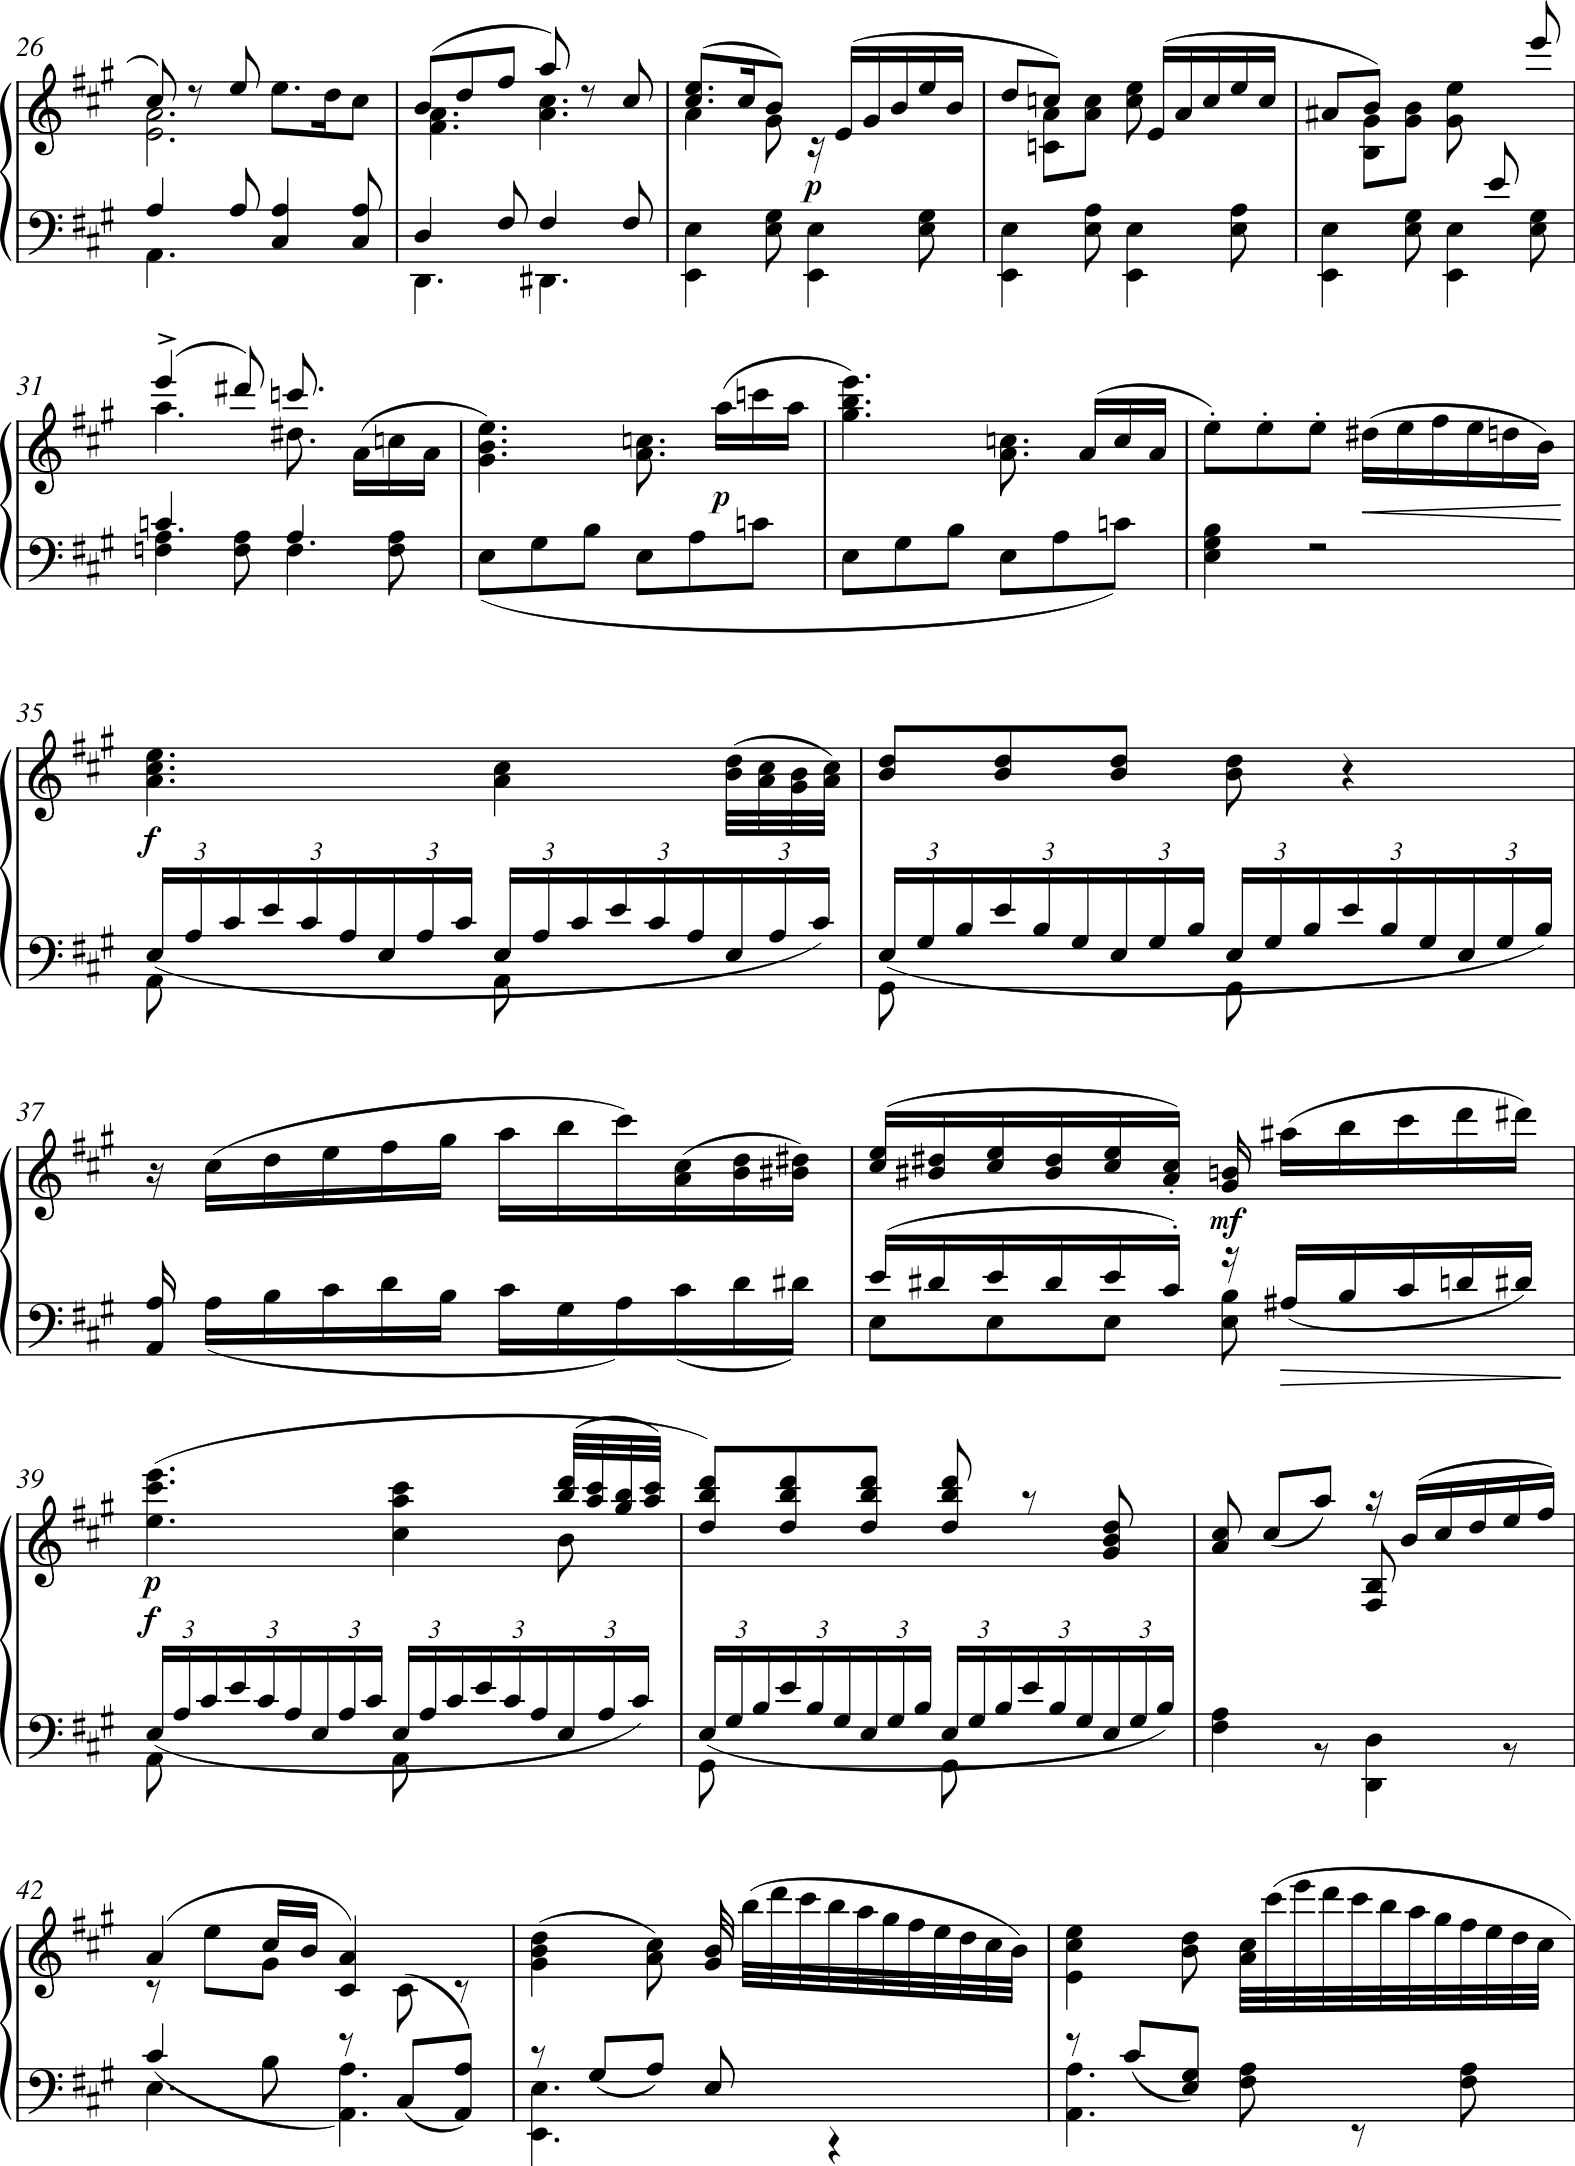

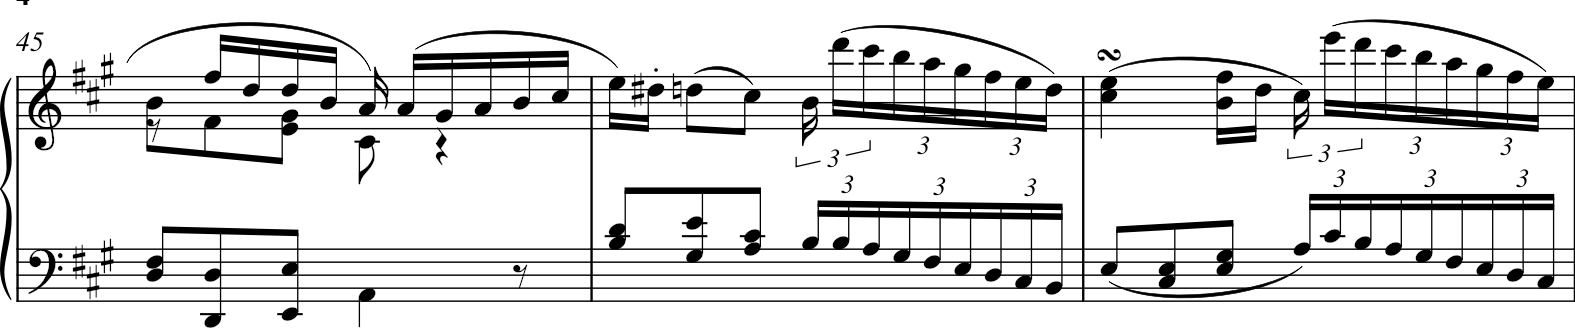

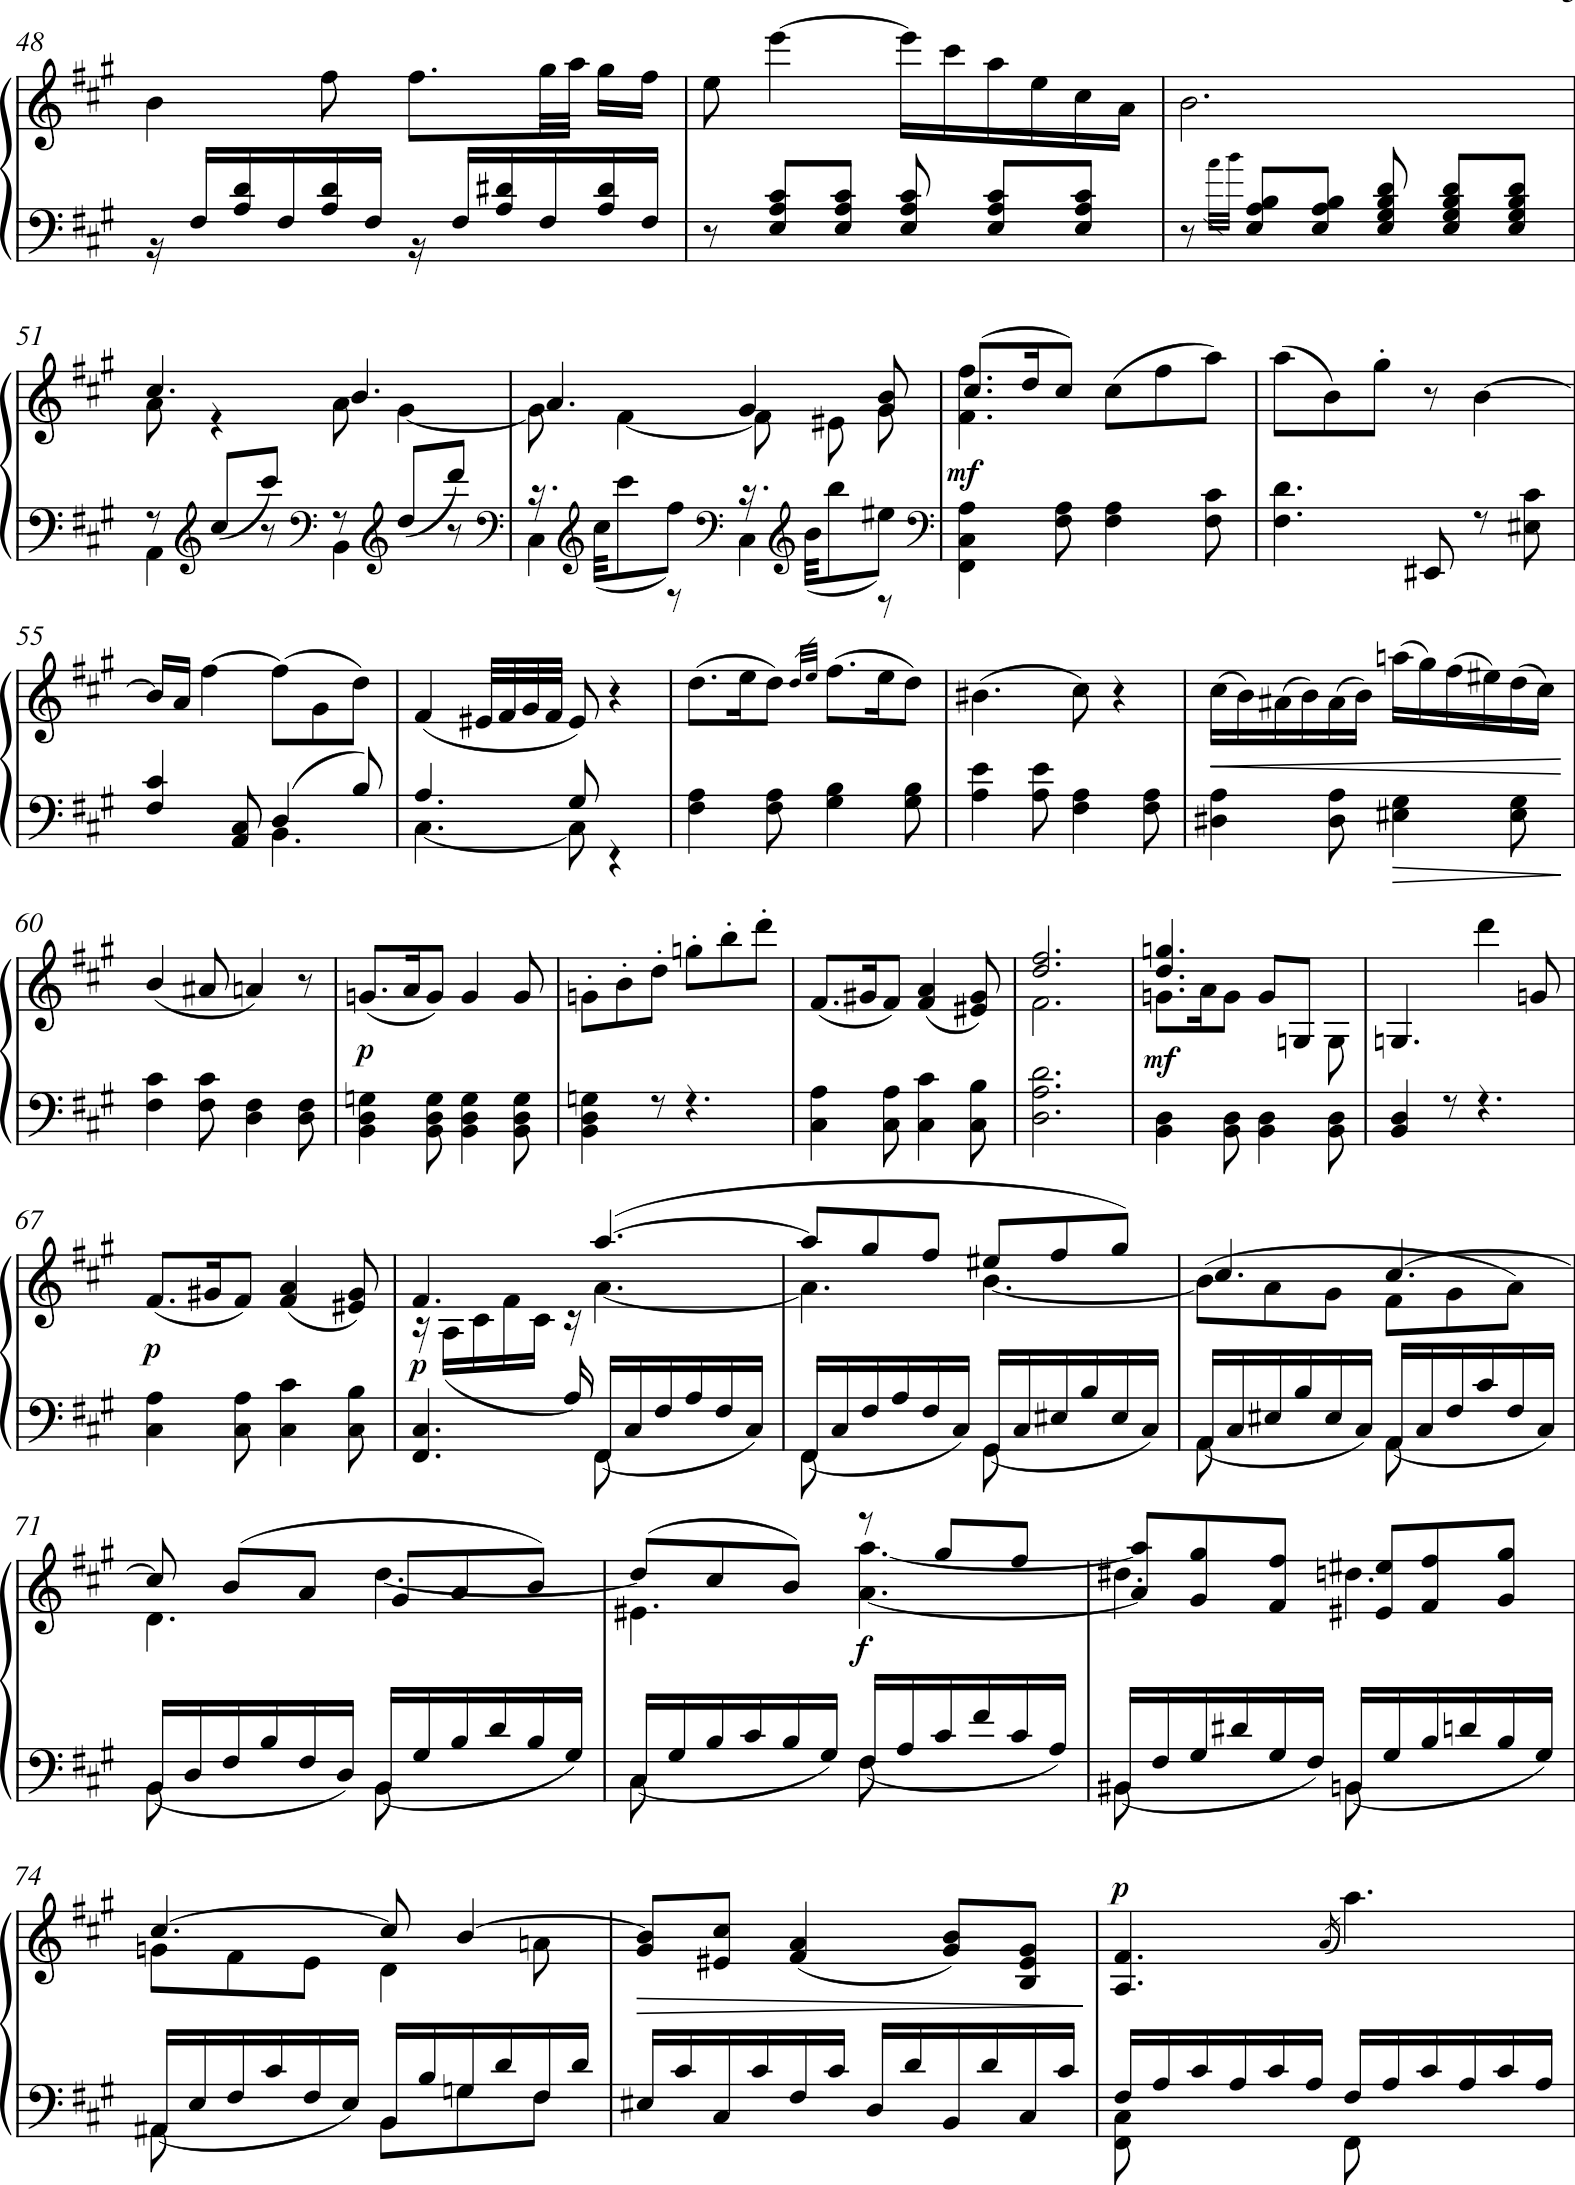

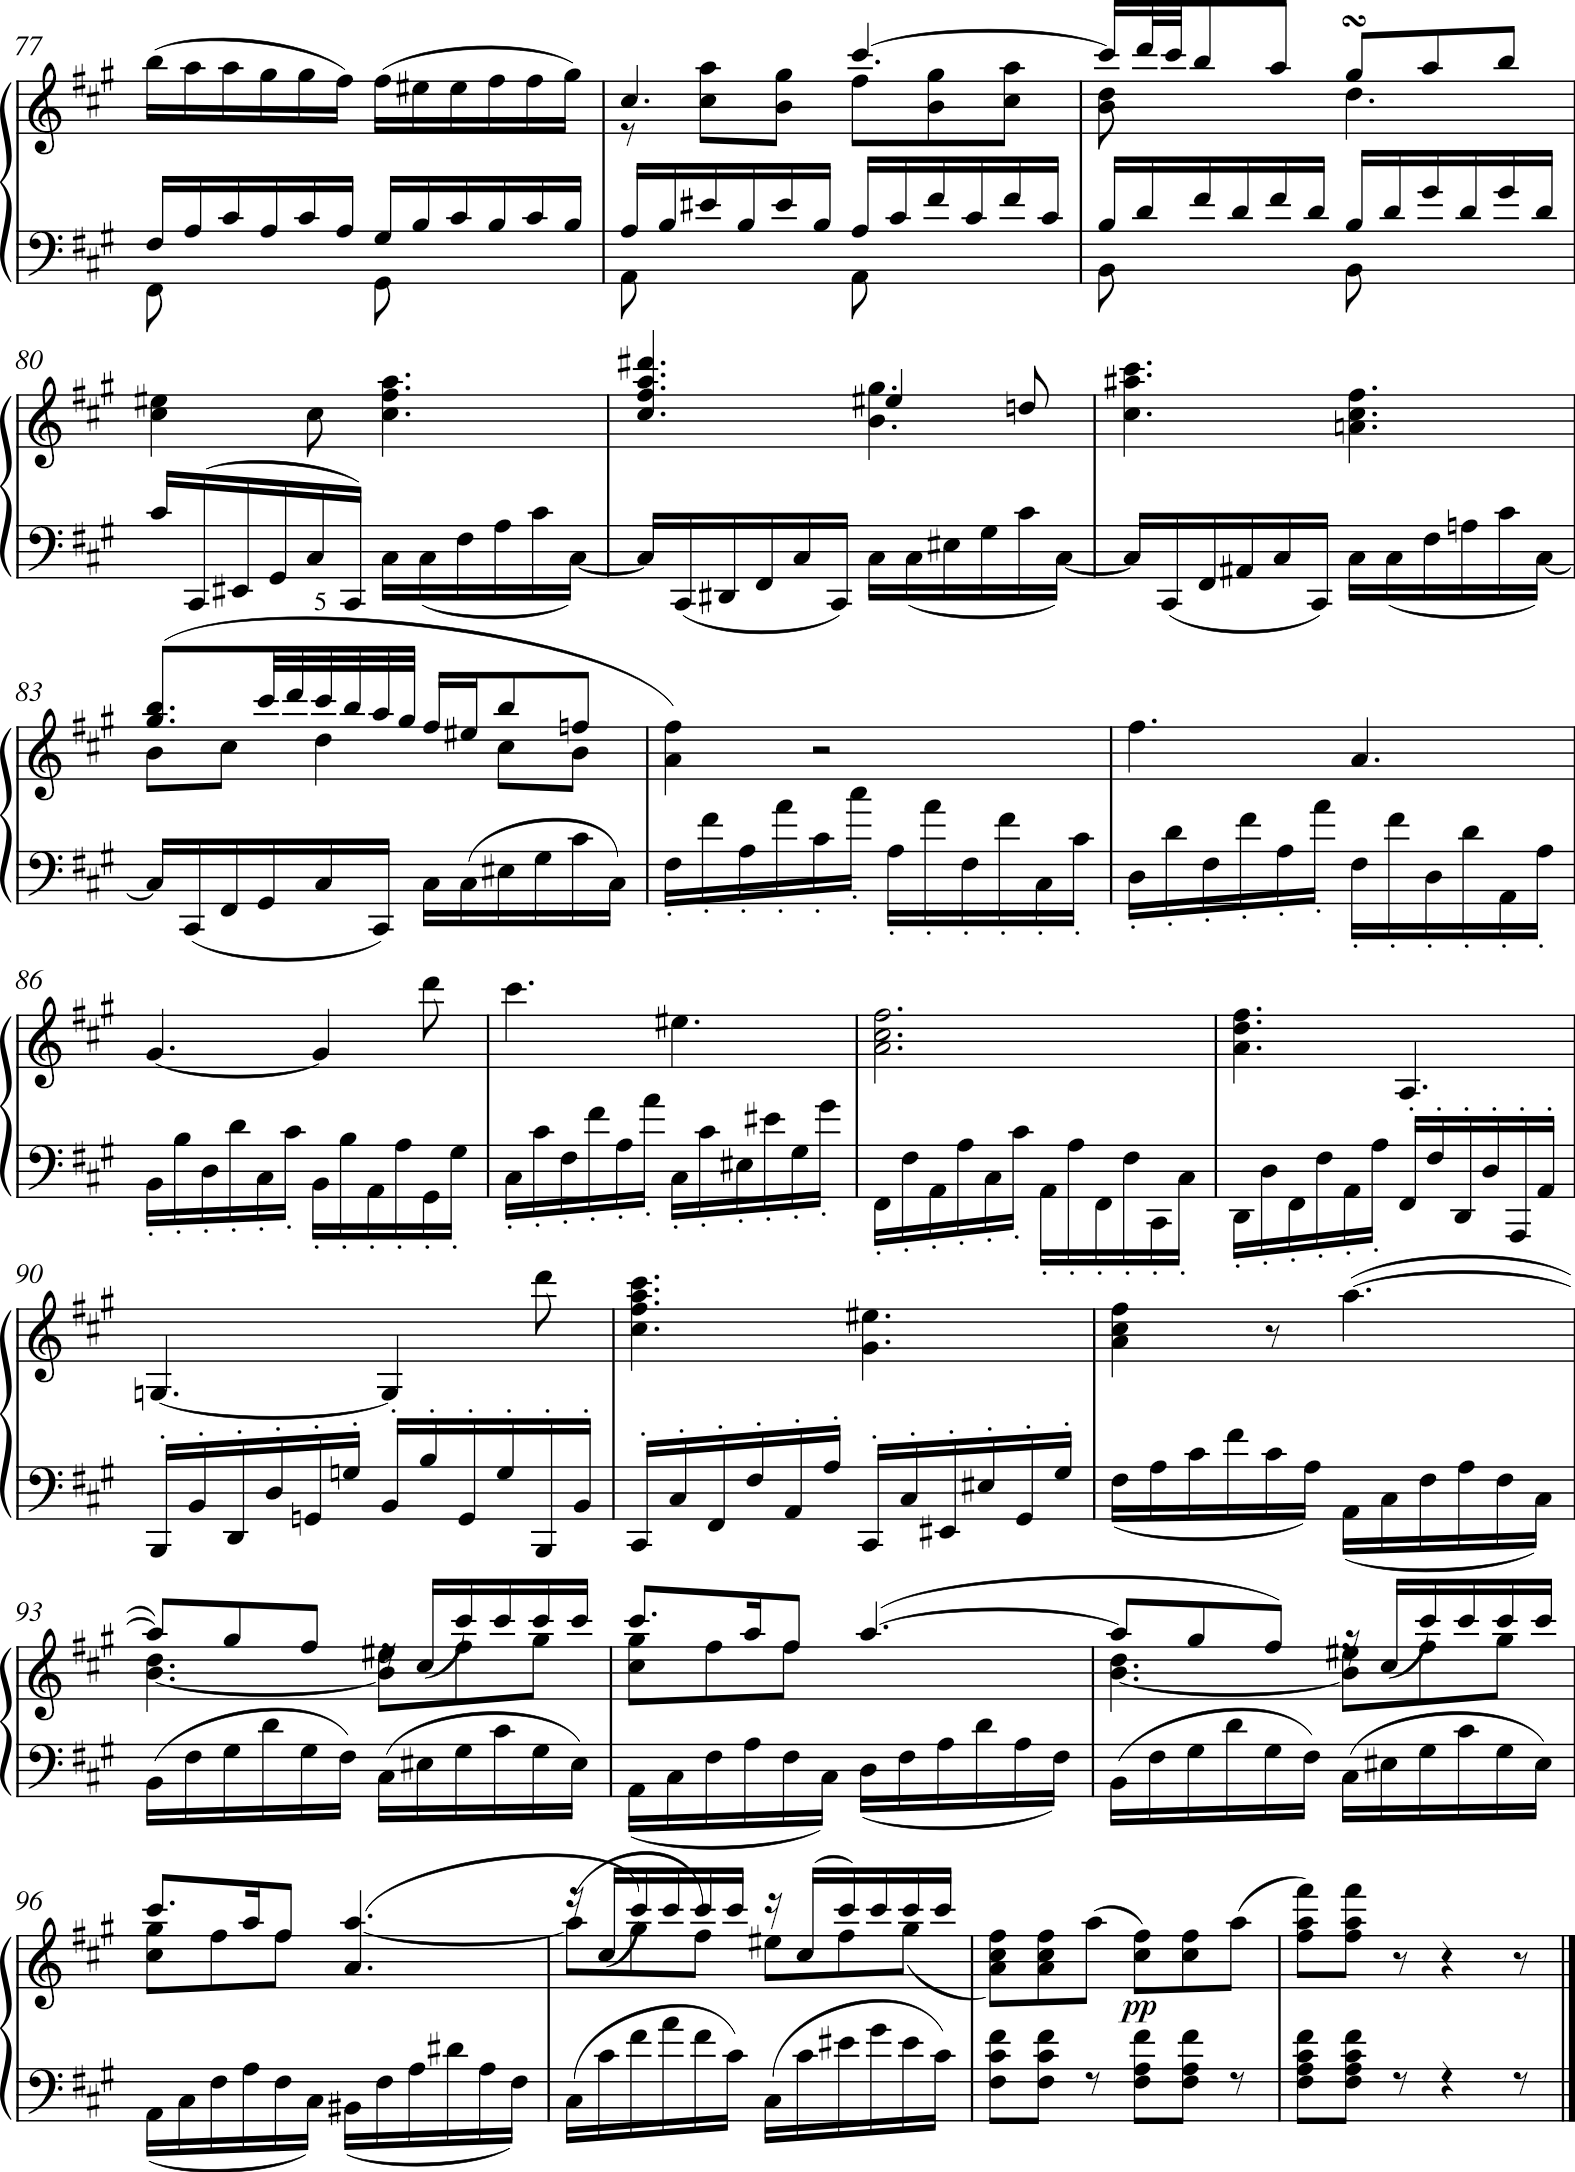

In [7]:
"""Cargar score"""

# score = converter.parse("data\Mozart_-_Lacrimosa_from_the_Requiem_in_D_minor.mxl")
score = converter.parse("data\Mozart_K.488_Piano_Concerto_23_in_A_2nd_mov._Adagio_for_piano_solo.mxl")
# score = converter.parse("partitura_generada.xml")
# score = converter.parse("data/humdrum-data/humdrum-data/beethoven/piano/sonata/beethoven-sonata01-1.krn")
score.show()

In [8]:
"""CODIDO ALFREDO"""
matriz = process_notes(score)
# matriz = np.load('array_merged.npy')
# matriz = np.load('data/beethoven-sonata01-1.npy',allow_pickle=True)

In [10]:
print(matriz[:5,:])

[[1 0.0 0.75 0.75 73.0 '6/8']
 [1 0.0 1.0 1.0 54.0 '6/8']
 [1 0.0 1.0 1.0 57.0 '6/8']
 [1 0.75 1.0 0.25 74.0 '6/8']
 [1 1.0 1.5 0.5 73.0 '6/8']]


In [153]:
path = r"data\humdrum-data-numpy\beethoven\piano\sonata\sonata14-3"
voices = []
for filename in sorted(os.listdir(path)):
    if filename.endswith(".npy"):
        try:
            arr = np.load(f"{path}/{filename}")
        except:
            arr = np.load(f"{path}/{filename}",allow_pickle=True)
        voices.append(arr)
combined = np.vstack([voices[i] for i in range(len(voices))])
print(combined)
matriz = combined[combined[:, -1].argsort()]        

[[  0.     0.25   0.25  -1.     1.  ]
 [  0.25   0.5    0.25  44.     1.  ]
 [  0.5    0.75   0.25  49.     1.  ]
 ...
 [  0.     1.     1.    49.   201.  ]
 [  1.     2.     1.    -1.   201.  ]
 [  2.     4.     2.    -1.   201.  ]]


In [154]:
data = matriz # la matriz
onsets_negras = np.array([]) # iniciamos array de onsets 
repeticiones = np.array([])   # array con número de repeticiones por onset
cum = 0 # iniciamos la suma acumulativa
for i in np.unique(data[:,4]): # iteramos compases
    array = data[np.where(data[:,4] == i),:][0] #seleccionamos array del compas
    if len(onsets_negras) > 0: # el primer compas cum = 0
        cum = np.max(array[:,1]) + cum # el segundo compas es cum = offset más alto
    array = array[~np.any(array[:,:] == -1, axis=1)] # para eliminar silencios
    array =  array[array[:, 0].argsort()]    # ordenar por onsets
    array,counts = np.unique(array[:,0], return_counts=True) # eliminar onsets repetidos
    array = array + cum # sumamos el cum
    repeticiones = np.concatenate((repeticiones,counts)) # lo añadimos 
    onsets_negras = np.concatenate((onsets_negras,array)) # lo añadimos 

"""onsets está listo para ser analizado por multitapers"""
# print(data)
print(onsets_negras)

[0.000e+00 2.500e-01 5.000e-01 ... 8.055e+02 8.075e+02 8.095e+02]


In [ ]:
# midi_to_note(80)

NameError: name 'midi_to_note' is not defined

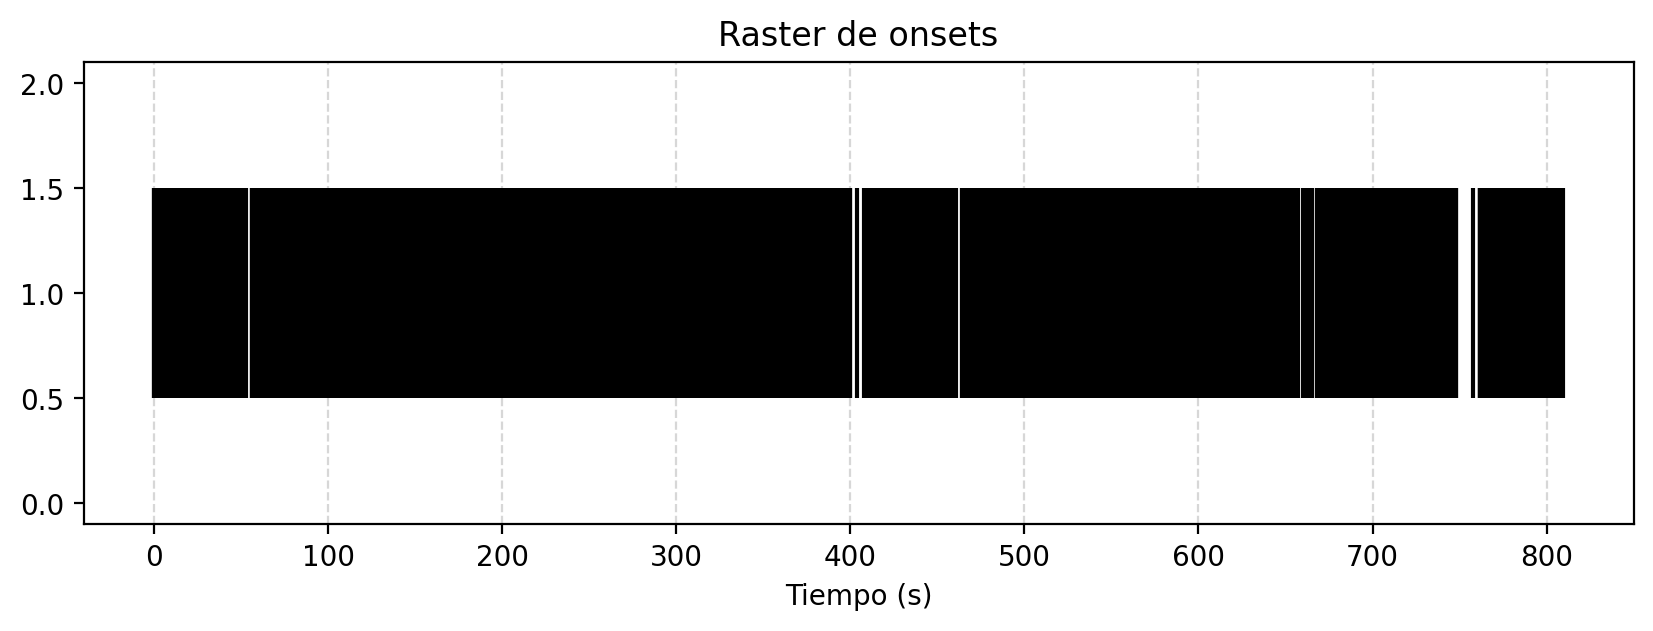

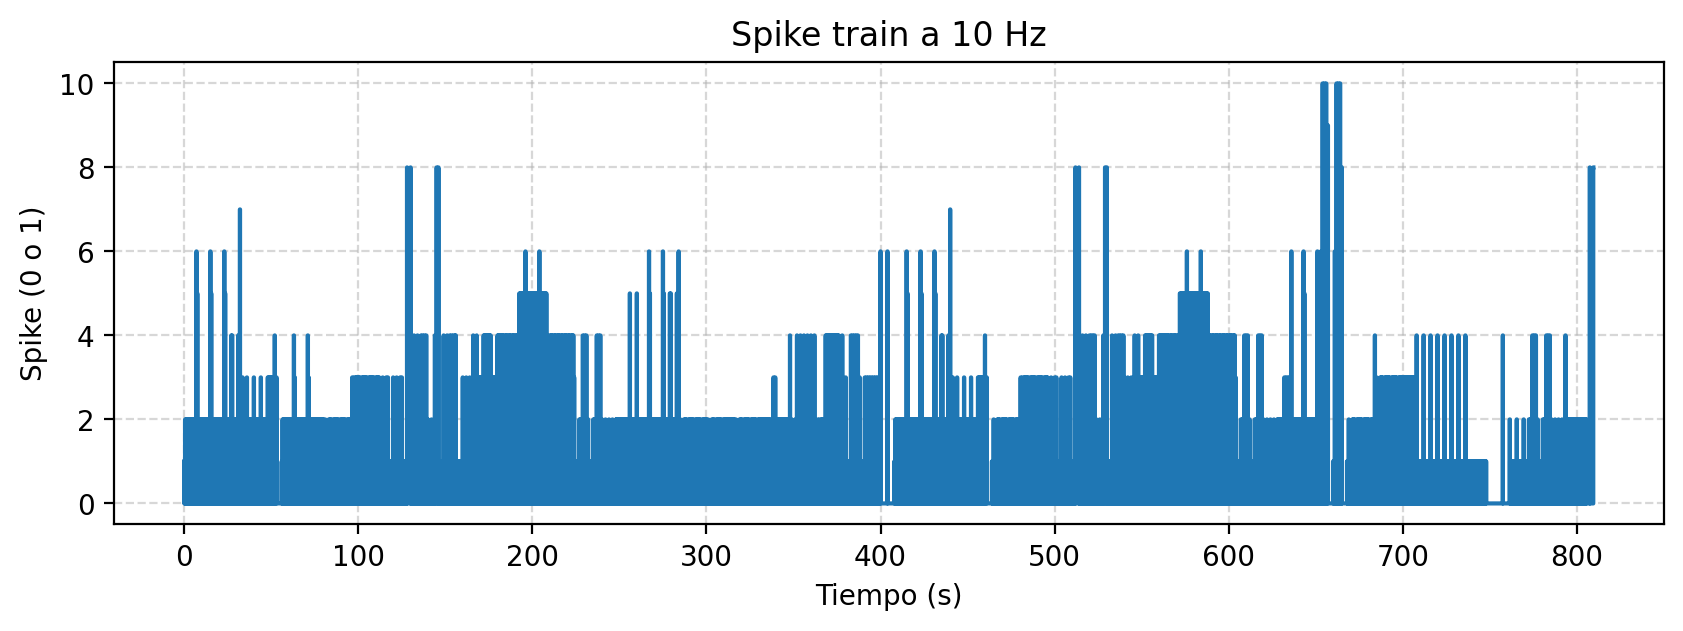

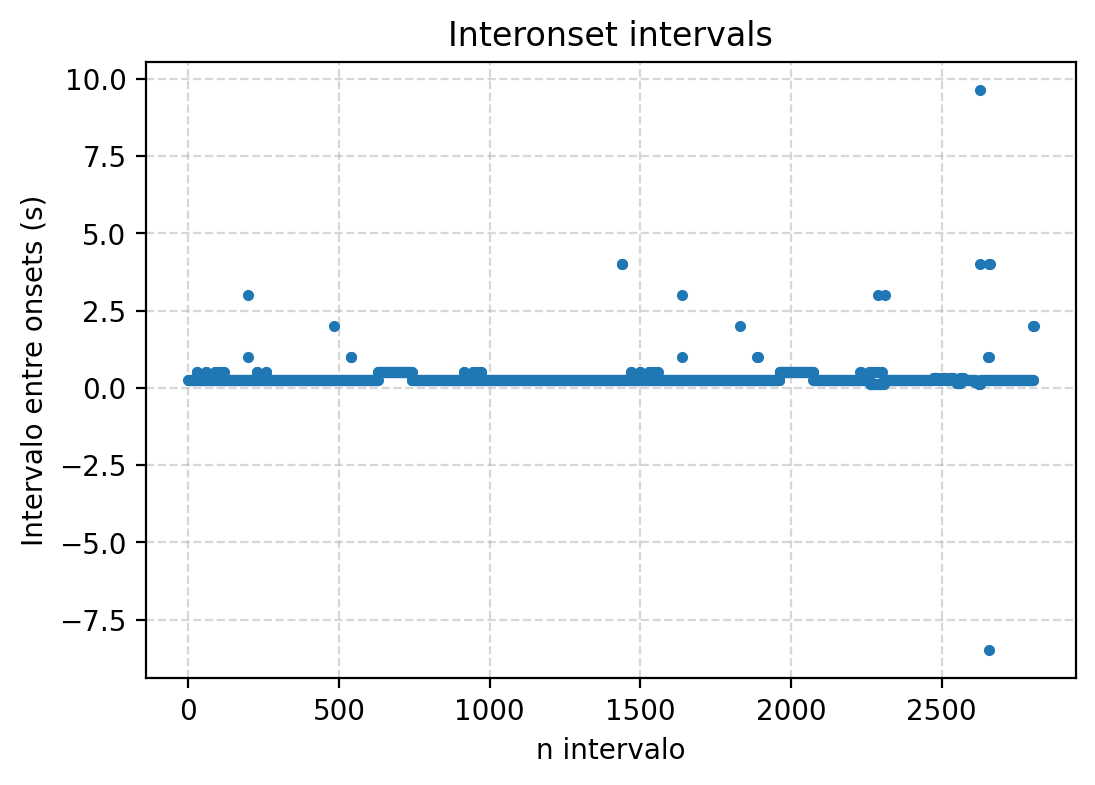

In [157]:
import numpy as np
# Ejemplo: tu matriz cargada
# matriz = np.loadtxt('mi_matriz.csv', delimiter=',')

# Calcular interonset intervals
interonset_intervals = np.diff(onsets_negras)

if False:
    interonset_intervals = np.random.permutation(interonset_intervals)
    onsets_negras = np.concatenate([[onsets_negras[0]], onsets_negras[0] + np.cumsum(interonset_intervals)])


# Crear spike train a 10 Hz (10 muestras por segundo)
fs = 10  # frecuencia de muestreo (Hz)
dt = 1 / fs

# Eje temporal
t_max = np.max(onsets_negras) + dt
t_axis = np.arange(0, t_max, dt)

# Inicializar spike train
spike_train = np.zeros_like(t_axis)

# Marcar spikes en el bin más cercano
for onset,weight in zip(onsets_negras,repeticiones):
    idx = np.argmin(np.abs(t_axis - onset))
    spike_train[idx] = weight

# --- Raster: spikes sobre eje temporal ---
plt.figure(figsize=(10, 3))
plt.eventplot(onsets_negras, orientation='horizontal', colors='black')
plt.xlabel('Tiempo (s)')
plt.title('Raster de onsets')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()

# --- Spike train como señal binaria ---
plt.figure(figsize=(10, 3))
plt.step(t_axis, spike_train, where='mid')
plt.xlabel('Tiempo (s)')
plt.ylabel('Spike (0 o 1)')
plt.title('Spike train a 10 Hz')
# plt.ylim(-0.1, 1.1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- Histograma de interonset intervals ---
plt.figure(figsize=(6, 4))
plt.plot(interonset_intervals,'.')
plt.xlabel('n intervalo')
plt.ylabel('Intervalo entre onsets (s)')
plt.title('Interonset intervals')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



In [132]:
np.shape(np.unique(interonset_intervals))[0]

20

In [ ]:
np.save('onsets.npy',onsets_negras)

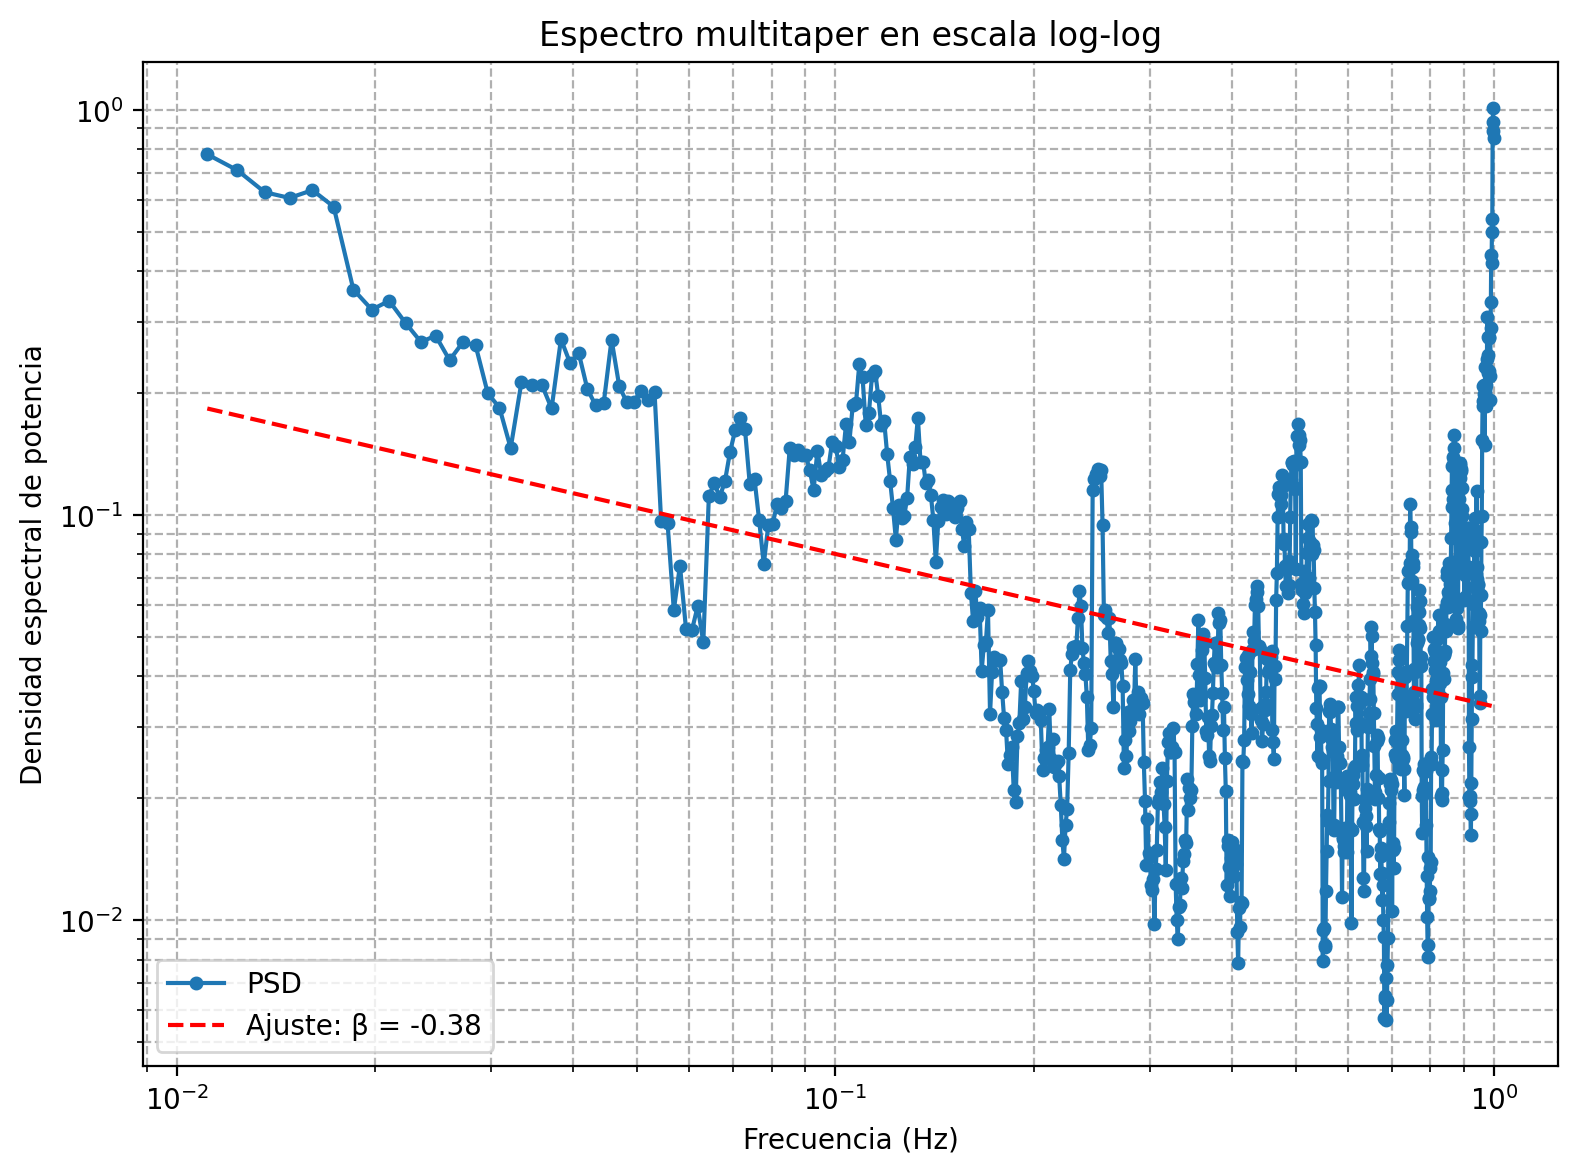

In [158]:
import numpy as np
import matplotlib.pyplot as plt
from mne.time_frequency import psd_array_multitaper
from scipy.stats import linregress

# 1. Interpolación lineal del spike train (si no se ha hecho antes)
# spike_train = interpolar_spike_train(onsets, fs)  # <- Aquí va tu función de interpolación

# 2. Cálculo del espectro de potencia usando multitaper
psd, freqs = psd_array_multitaper(
    spike_train,
    sfreq=fs,
    fmin=0.01,
    fmax=1.0,
    adaptive=True,
    normalization='full',
    verbose=False
)

# 3. Transformación a escala log-log
mask = (freqs > 0)  # Evitar log(0)
log_freqs = np.log10(freqs[mask])
log_psd = np.log10(psd[mask])

# 4. Ajuste lineal en la región de interés (región de potencias tipo ley de potencias)
roi = (freqs[mask] >= 0.01) & (freqs[mask] <= 1.0)
slope, intercept, r_value, p_value, std_err = linregress(log_freqs[roi], log_psd[roi])

# 5. Gráfica del espectro y la ley de potencias ajustada
plt.figure(figsize=(8, 6))
plt.plot(freqs, psd, 'o-', label='PSD', markersize=4)
plt.plot(
    freqs[mask][roi],
    10**(intercept + slope * log_freqs[roi]),
    'r--',
    label=f'Ajuste: β = {slope:.2f}'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia')
plt.title('Espectro multitaper en escala log-log')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()


In [ ]:
print(J_univariante(interpolador(generar_uniforme_centrada(10000,1e-5),'lineal',10)[1]))

0.8897919029200937


4401
0.7294621421328904


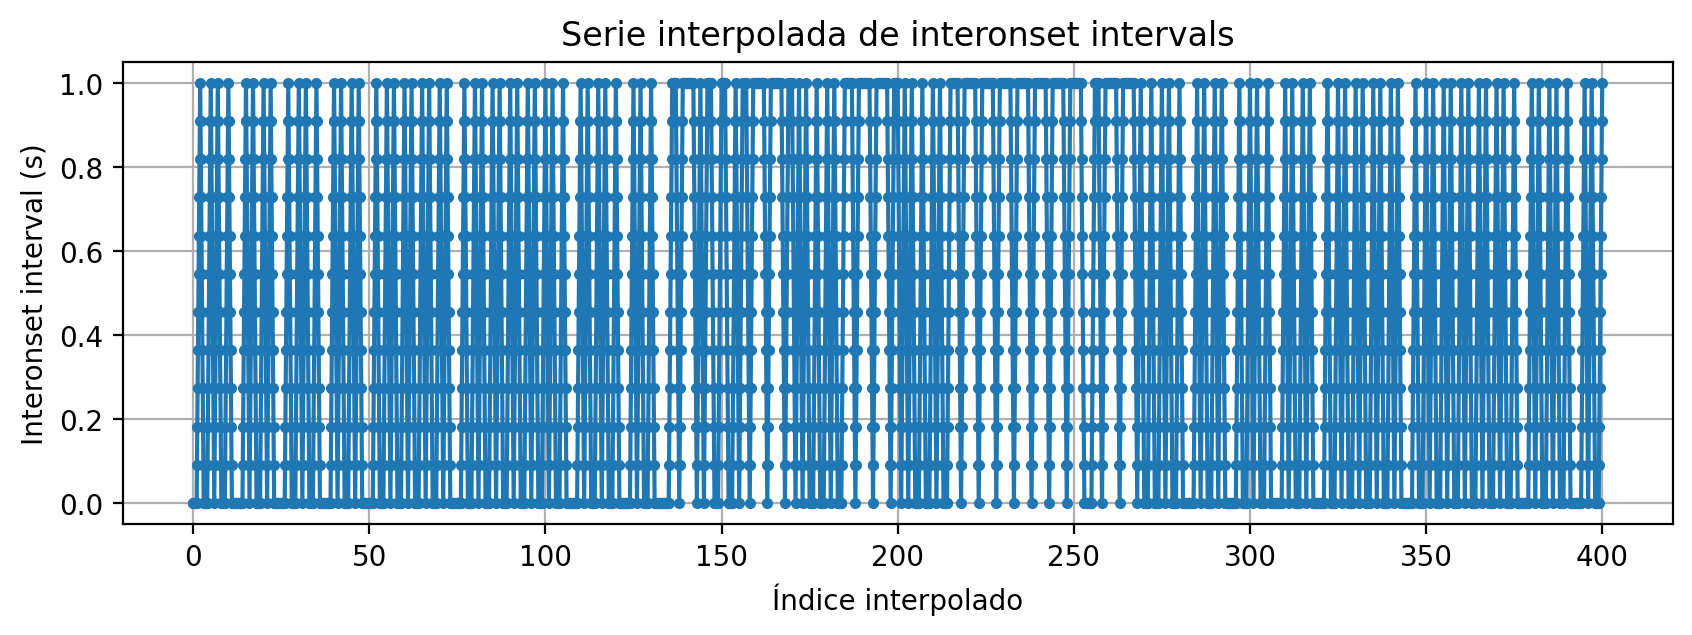

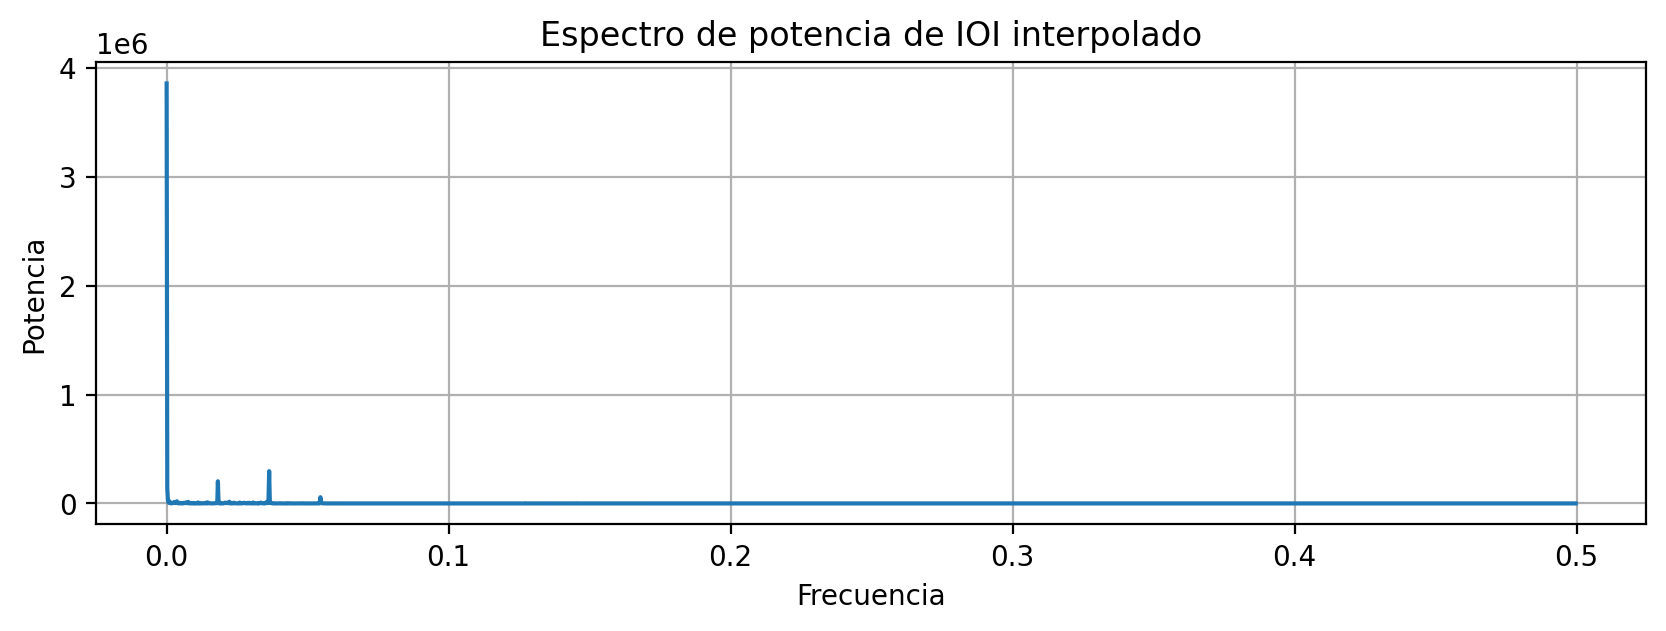

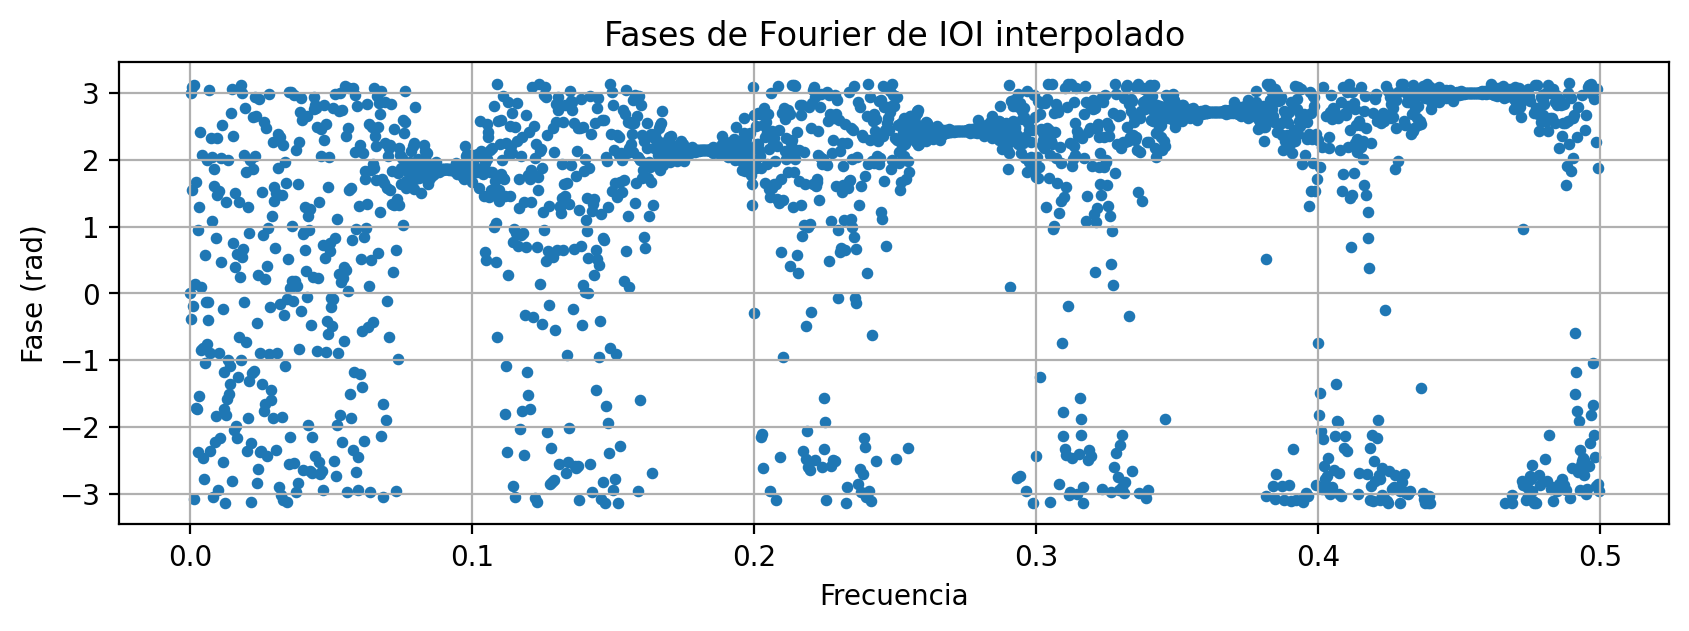

In [ ]:
from scipy.interpolate import PchipInterpolator
from scipy.fft import fft


x_new, ioi_interp = interpolador(spike_train, method='lineal', size=10)
print(len(ioi_interp))
# === FFT ===
fft_result = fft(ioi_interp)
power = np.abs(fft_result)**2
phase = np.angle(fft_result)

# === Frecuencias asociadas ===
fs = 1  # Como estamos trabajando en índice de IOIs (no en tiempo real), fs=1
freqs = np.fft.fftfreq(len(ioi_interp), d=1/fs)

# === Gráficas ===

# Serie interpolada
plt.figure(figsize=(10, 3))
plt.plot(x_new, ioi_interp,'.-')
plt.title('Serie interpolada de interonset intervals')
plt.xlabel('Índice interpolado')
plt.ylabel('Interonset interval (s)')
plt.grid(True)

# Espectro de potencia
plt.figure(figsize=(10, 3))
plt.plot(freqs[:len(freqs)//2], power[:len(freqs)//2])
plt.title('Espectro de potencia de IOI interpolado')
plt.xlabel('Frecuencia')
plt.ylabel('Potencia')
plt.grid(True)

# Fases de Fourier
print(J_univariante(ioi_interp))
plt.figure(figsize=(10, 3))
plt.scatter(freqs[:len(freqs)//2], phase[:len(freqs)//2], s=10)
plt.title('Fases de Fourier de IOI interpolado')
plt.xlabel('Frecuencia')
plt.ylabel('Fase (rad)')
plt.grid(True)

plt.show()
